# Fade the release, exit at a level

Every other notebook in this folder unwinds on a **clock**: enter at T+2, leave at T+60, whatever the
price did in between. This one unwinds on a **level** — a take-profit, a stop, an optional trailing
stop, and a time stop only as the backstop. That is a different strategy, not a different report, and
it needs its own book because the exit is now path-dependent.

### Why the exit rule has to go through the engine

A clock exit can be priced by arithmetic: two timestamps, two prices, done. A level exit cannot. The
question "did this trade touch −1.5 bp before it touched +0.25 bp" is answered by walking the path
minute by minute, and the answer depends on market state at each step. That is exactly the job
`QueryDrivenBacktest` exists to do, so the headline book here is built by the **real
`USTFuturesMDP` + engine**, with the fetcher disarmed for the whole run.

The fast path exists too, because a sweep over hundreds of brackets cannot afford an engine build per
cell. It is only trustworthy because §4 ties it back to the engine and **asserts** they agree.

### `mode="close"` is not a detail

`ExitRule` defaults to `mode="intrabar"`, which triggers off the bar's High/Low. The engine cannot see
inside a bar — it polls once a minute and sees closes. So an intrabar rule and the engine disagree by
construction, and every tie-out in this study that passed did so in `"close"` mode. This notebook
defaults to `"close"` throughout: a desk polling the screen once a minute, which is both what the
engine can verify and the more conservative of the two.

### The two ways this strategy flatters itself

**A stop is a cost, not a saving.** A stop fill crosses the spread *and* slips, so a stop-heavy rule
is charged roughly twice a round trip. `stop_slip_ticks` is set to a full tick for that reason.

**A fractional bracket is scale-free and an absolute one is not.** A 12 bp CPI burst and a 1 bp burst
do not deserve the same absolute target, so `tp_frac`/`sl_frac` scale with the trade's own move. Both
parameterisations are swept in §6 and the family correction in §8 is charged for both.

---

> **Known before this notebook starts.** The clock-exit fade on raw releases loses. This notebook asks
> whether a *level* exit rescues it, on the one release (CPI) and one instrument (TY) where the raw
> study was least hopeless. If it does not, that is the answer.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, copy, itertools, time, warnings
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-eco"
HERE = Path(REPO) / "notebooks" / "backtests" / "econ_release_fade"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "figure.autolayout": True})

import econ_fade_common as G
import econ_fade_config as C
import econ_fade_exits as X
import econ_fade_mdp_exits as MX
from econ_fade_prewarm import load_events

from RVUtils.StatisticalFinance import (
    ras_bound, romano_wolf, selection_bias_pvalue, shared_sign_flip_null, timer_pvalue,
)

print("modules loaded")

modules loaded


## 1. The configuration

Everything the strategy does is in this cell. `EVENTS` selects which releases, `SIGNAL` decides the
side and how big a burst is worth trading, `BRACKET` is the exit, and `COST_BP` is what a round trip
costs.

One ZN tick is 1/64 of a point, about **0.2389 bp** of yield on the 10-year, and the bid-ask is a tick
wide — so a round trip that crosses it costs about one tick. That is the number every P&L in this
notebook is net of.

In [2]:
# ---------------------------------------------------------------- the knobs
NAME       = "cpi_ty"
INSTRUMENT = {"family": "ust", "root": "TY", "rank": 1}

EVENTS = {"currencies": ["USD"], "impacts": ["high", "medium"], "require_actual": True,
          "include_cb_decisions": False, "titles_include": [r"\bCPI\b"]}

TIMING = {"measure_start_min": 0, "measure_end_min": 1, "entry_offset_min": 2,
          "exit_offset_min": 60}

SIGNAL = {"direction": "fade",      # fade | momentum
          "min_move_bp": 3.0}       # only trade a burst at least this big

BRACKET = dict(tp_frac=0.25,        # target = 25% of THIS trade's own burst
               sl_frac=1.5,         # stop   = 150% of it
               tp_bp=None, sl_bp=None,
               trail_bp=None,       # None | bp; a trail forces the slow path
               time_stop_min=118,   # backstop only
               min_hold_min=0,
               stop_slip_ticks=1.0,
               mode="close")        # "close" is what the ENGINE can see -- see the intro

COST_BP = 0.2389                    # one ZN tick, one round trip

# ------------------------------------------------------------- derived once
CFG  = C.spec(NAME, instrument=INSTRUMENT, events=EVENTS, timing=TIMING, signal=SIGNAL)
RULE = X.ExitRule(name="headline", **BRACKET)

print(json.dumps(CFG, indent=1, default=str))
print()
print("bracket:", RULE)

{
 "name": "cpi_ty",
 "instrument": {
  "family": "ust",
  "root": "TY",
  "rank": 1
 },
 "events": {
  "currencies": [
   "USD"
  ],
  "impacts": [
   "high",
   "medium"
  ],
  "titles_include": [
   "\\bCPI\\b"
  ],
  "titles_exclude": null,
  "require_actual": true,
  "include_cb_decisions": false,
  "start": null,
  "end": null,
  "weekdays": null,
  "surprise": "any",
  "min_events_in_minute": 1,
  "release_times_ny": null
 },
 "timing": {
  "measure_start_min": 0,
  "measure_end_min": 1,
  "entry_offset_min": 2,
  "exit_offset_min": 60,
  "max_staleness_min": 5,
  "same_day_exit": true
 },
 "signal": {
  "direction": "fade",
  "source": "move",
  "min_move_bp": 3.0,
  "max_move_bp": null
 },
 "sizing": "equal",
 "contracts": 1,
 "cost_bp": 0.0
}

bracket: ExitRule(name='headline', tp_bp=None, tp_frac=0.25, sl_bp=None, sl_frac=1.5, trail_bp=None, time_stop_min=118, min_hold_min=0, stop_slip_ticks=1.0, mode='close')


## 2. Data, book, and the funnel

`load_events` reads the ForexFactory calendar; `bars.pkl` is the warmed Barchart minute cache;
`dv01.json` is the measured per-contract DV01 that converts price into basis points.

The **funnel** is the part worth reading. It accounts for every calendar event that did not become a
trade, so a book that looks clean because it quietly dropped two thirds of its events cannot hide.

In [3]:
t0 = time.time()
G.load_bar_cache()
G.load_dv01()
raw = load_events()
print(f"loaded in {time.time()-t0:.1f}s   {len(raw):,} release minutes, "
      f"{raw['release_ts'].min()} .. {raw['release_ts'].max()}")

book = X.build_base_book(CFG, raw)
print(f"\nbook: {len(book.events):,} tradeable events on {book.instrument.root}")
print("\n--- funnel: why every other event is not here ---")
for k, v in book.funnel.items():
    print(f"  {k:28s} {v}")

loaded in 4.2s   2,870 release minutes, 2019-01-03 13:15:00+00:00 .. 2026-08-07 12:30:00+00:00

book: 38 tradeable events on TY

--- funnel: why every other event is not here ---
  raw                          2870
  filter_drops                 {'not_a_data_release': 830, 'central_bank_decision': 72, 'title_not_included': 1877}
  after_filters                91
  overlap_dropped              0
  after_overlap                91
  gate_reasons                 {'ok': 90, 'no_bars_that_day': 1}
  after_gate                   90
  signal_drops                 {'zero_move': 6, 'move_below_threshold': 46}
  TRADEABLE                    38


In [4]:
ev = book.events.copy()
ev["ny"] = pd.to_datetime(ev["release_ts"], utc=True).dt.tz_convert("America/New_York")
print("the book, by year and by contract")
print(pd.crosstab(ev["ny"].dt.year, ev["symbol"]).to_string())
print(f"\nburst size (bp):  mean {ev.move_bp.abs().mean():.2f}   "
      f"median {ev.move_bp.abs().median():.2f}   max {ev.move_bp.abs().max():.2f}")
ev[["release_ts", "symbol", "move_bp", "side", "entry_px", "px_per_bp"]].head(8)

the book, by year and by contract
symbol  TYH22  TYH23  TYH24  TYH25  TYH26  TYM21  TYM22  TYM23  TYM24  TYM25  TYU21  TYU22  TYU23  TYU24  TYU25  TYU26  TYZ22  TYZ23  TYZ24  TYZ25
ny                                                                                                                                                
2021        0      0      0      0      0      1      0      0      0      0      1      0      0      0      0      0      0      0      0      0
2022        1      1      0      0      0      0      2      0      0      0      0      3      0      0      0      0      3      0      0      0
2023        0      2      0      0      0      0      0      1      0      0      0      0      2      0      0      0      0      2      0      0
2024        0      0      2      0      0      0      0      0      2      0      0      0      0      2      0      0      0      0      2      0
2025        0      0      0      2      0      0      0      0      0      2      0 

,release_ts,symbol,move_bp,side,entry_px,px_per_bp
0,2021-05-12 12:30:00+00:00,TYM21,4.001775,1.0,132.250000,0.070281
1,2021-07-13 12:30:00+00:00,TYU21,3.714030,1.0,133.281250,0.071519
2,2022-02-10 13:30:00+00:00,TYH22,4.474667,1.0,126.343750,0.069838
3,2022-04-12 12:30:00+00:00,TYM22,-8.179777,-1.0,120.343750,0.063037
4,2022-05-11 12:30:00+00:00,TYM22,8.179777,1.0,118.359375,0.063037
5,2022-06-10 12:30:00+00:00,TYU22,6.628244,1.0,117.609375,0.063648
6,2022-07-13 12:30:00+00:00,TYU22,10.065111,1.0,118.125000,0.063648
7,2022-08-10 12:30:00+00:00,TYU22,-15.711393,-1.0,120.625000,0.063648


## 3. The engine run

`prime_ust_cache` writes the warmed bars into the MDP's **own** DiskCache under its exact key
contract, then `open_ust_mdp(armed=False)` replaces the Barchart fetcher with a raise. From that point
"no network was used" is a property the run *enforces* rather than a claim — if the cache misses a
minute the run raises `NetworkForbidden` instead of quietly reaching out.

Note the prime covers **every minute of the holding window**, not just entry and exit: the engine
marks the open position to market at each step of the grid, so any gap is a real hole.

In [5]:
mdp = MX.open_ust_mdp(armed=False)          # fetcher disarmed for the whole notebook
wanted = MX.wanted_minutes(book.events, RULE.time_stop_min)
print(f"{len(wanted):,} (symbol, minute) pairs the engine may ask for")

t0 = time.time()
stats = MX.prime_ust_cache(mdp, wanted, show_progress=False)
print(f"primed in {time.time()-t0:.1f}s: {stats}")
print(f"  coverage: {stats['written'] / max(1, len(wanted)) * 100:.1f}% of requested minutes had a real bar")
print("  (a minute with no print stays a MISS -- the MDP resolves to the nearest bar, so writing")
print("   a neighbour's price would fabricate one)")

4,636 (symbol, minute) pairs the engine may ask for


primed in 6.4s: {'written': 4636, 'no_bar': 0, 'no_day': 0}
  coverage: 100.0% of requested minutes had a real bar
  (a minute with no print stays a MISS -- the MDP resolves to the nearest bar, so writing
   a neighbour's price would fabricate one)


In [6]:
t0 = time.time()
engine = MX.run_bracket_engine(book, RULE, mdp, cost_bp=COST_BP, show_progress=False)
print(f"engine booked {len(engine):,} trades in {time.time()-t0:.1f}s")
# the engine returns the PORTFOLIO's closed-position log, so its columns are the
# engine's own -- entry_px, realized_pnl, holding_period_steps -- not the fast
# path's bar-level bookkeeping.
engine[["release_ts", "symbol", "move_bp", "side", "entry_px", "exit_reason",
        "hold_min", "dv01_usd", "realized_pnl", "pnl_bp_gross", "pnl_bp"]].head(10)

engine booked 38 trades in 6.8s


,release_ts,symbol,move_bp,side,entry_px,exit_reason,hold_min,dv01_usd,realized_pnl,pnl_bp_gross,pnl_bp
0,2021-05-12 12:30:00+00:00,TYM21,4.001775,1.0,132.250000,time_stop,118.0,70.281311,-234.375,-3.334813,-3.573713
1,2021-07-13 12:30:00+00:00,TYU21,3.714030,1.0,133.281250,target,3.0,71.519342,78.125,1.092362,0.853462
2,2022-02-10 13:30:00+00:00,TYH22,4.474667,1.0,126.343750,target,8.0,69.837602,78.125,1.118667,0.879767
3,2022-04-12 12:30:00+00:00,TYM22,-8.179777,-1.0,120.343750,target,7.0,63.036560,156.250,2.478720,2.239820
4,2022-05-11 12:30:00+00:00,TYM22,8.179777,1.0,118.359375,target,67.0,63.036560,156.250,2.478720,2.239820
5,2022-06-10 12:30:00+00:00,TYU22,6.628244,1.0,117.609375,target,3.0,63.648078,109.375,1.718434,1.479534
6,2022-07-13 12:30:00+00:00,TYU22,10.065111,1.0,118.125000,target,105.0,63.648078,171.875,2.700396,2.461496
7,2022-08-10 12:30:00+00:00,TYU22,-15.711393,-1.0,120.625000,target,17.0,63.648078,250.000,3.927848,3.688948
8,2022-09-13 12:30:00+00:00,TYZ22,14.045263,1.0,115.250000,time_stop,118.0,58.961160,-140.625,-2.385045,-2.623945
9,2022-10-13 12:30:00+00:00,TYZ22,14.840278,1.0,110.593750,time_stop,118.0,58.961160,-125.000,-2.120040,-2.358940


## 4. Tie-out — the fast path must reproduce the engine exactly

Everything after this section uses `run_bracket_fast`, which is the same fill model without the
engine build. That is only legitimate if the two agree, so this cell **asserts** it: same trade count,
same exit reason on every trade, and P&L identical to floating point.

This tie-out is not ceremony. It failed the first time it was run — max |diff| 13.5 bp and exit
reasons matching on only 73 of 84 trades — and the four bugs it exposed are recorded in the PR. A
check that has never failed is a check you have not tested.

In [7]:
fast = MX.run_bracket_fast(book, RULE, cost_bp=COST_BP)
print(f"engine {len(engine):,} trades   fast {len(fast):,} trades")

a = engine.set_index("tag").sort_index()
b = fast.set_index("tag").sort_index()
shared = a.index.intersection(b.index)
assert len(shared) == len(a) == len(b), (
    f"trade sets differ: engine {len(a)}, fast {len(b)}, shared {len(shared)}")

dpnl = (a.loc[shared, "pnl_bp"] - b.loc[shared, "pnl_bp"]).abs()
same_reason = int((a.loc[shared, "exit_reason"] == b.loc[shared, "exit_reason"]).sum())
print(f"max |pnl_bp diff|   : {dpnl.max():.3e}")
print(f"exit reasons agree  : {same_reason} / {len(shared)}")

assert dpnl.max() < 1e-9, f"fast path disagrees with the engine by {dpnl.max():.4f} bp"
assert same_reason == len(shared), "fast path picks a different exit reason"
print("\nTIE-OUT PASSED -- the fast path is the engine, and the sweeps below are legitimate")

engine 38 trades   fast 38 trades
max |pnl_bp diff|   : 1.776e-15
exit reasons agree  : 38 / 38

TIE-OUT PASSED -- the fast path is the engine, and the sweeps below are legitimate


## 5. What the headline configuration is worth

In [8]:
def stats_of(df, label="book"):
    p = df["pnl_bp"].to_numpy(float)
    wins, losses = p[p > 0], p[p <= 0]
    sd = p.std(ddof=1) if len(p) > 1 else 0.0
    return {
        "label": label, "trades": len(p), "hit_rate": float((p > 0).mean()),
        "gross_bp": float(df["pnl_bp_gross"].mean()), "net_bp": float(p.mean()),
        "total_net_bp": float(p.sum()),
        "avg_win": float(wins.mean()) if len(wins) else np.nan,
        "avg_loss": float(losses.mean()) if len(losses) else np.nan,
        "payoff": float(wins.mean() / abs(losses.mean())) if len(wins) and len(losses) else np.nan,
        "sr_per_trade": float(p.mean() / sd) if sd > 0 else 0.0,
        "t_stat": float(p.mean() / (sd / np.sqrt(len(p)))) if sd > 0 else 0.0,
        "avg_hold_min": float(df["hold_min"].mean()),
        "pct_target": float((df.exit_reason == "target").mean()),
        "pct_stop": float(df.exit_reason.isin(["stop", "trail"]).mean()),
        "pct_time": float((df.exit_reason == "time_stop").mean()),
    }

hl = stats_of(engine, "headline (engine)")
print(pd.Series(hl).to_frame("value").to_string())
print()
print("read it as: a", f"{hl['hit_rate']*100:.1f}%", "hit rate paying", f"{hl['net_bp']:+.4f}",
      "bp per trade net of one tick, t =", f"{hl['t_stat']:.2f}")

                          value
label         headline (engine)
trades                       38
hit_rate               0.684211
gross_bp               0.206723
net_bp                -0.032177
total_net_bp           -1.22272
avg_win                2.023971
avg_loss              -4.487164
payoff                 0.451058
sr_per_trade          -0.008234
t_stat                -0.050758
avg_hold_min               49.0
pct_target             0.684211
pct_stop               0.052632
pct_time               0.263158

read it as: a 68.4% hit rate paying -0.0322 bp per trade net of one tick, t = -0.05


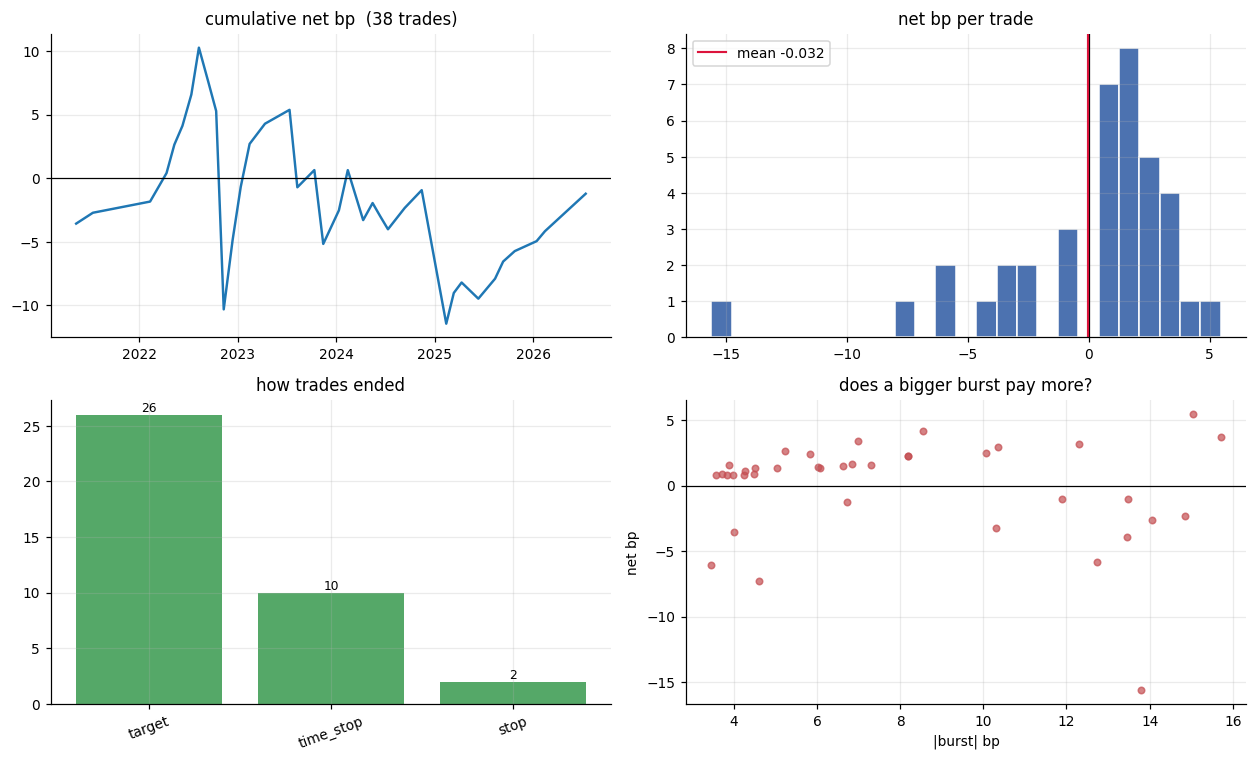

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7))

d = engine.sort_values("release_ts")
ts = pd.to_datetime(d["release_ts"], utc=True).dt.tz_convert("America/New_York")
ax[0, 0].plot(ts, d["pnl_bp"].cumsum(), lw=1.6, color="#1f77b4")
ax[0, 0].axhline(0, color="k", lw=0.8)
ax[0, 0].set_title(f"cumulative net bp  ({len(d)} trades)")
ax[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax[0, 1].hist(d["pnl_bp"], bins=25, color="#4c72b0", edgecolor="white")
ax[0, 1].axvline(0, color="k", lw=0.8)
ax[0, 1].axvline(d["pnl_bp"].mean(), color="crimson", lw=1.4,
                 label=f"mean {d['pnl_bp'].mean():+.3f}")
ax[0, 1].legend(); ax[0, 1].set_title("net bp per trade")

mix = d["exit_reason"].value_counts()
ax[1, 0].bar(range(len(mix)), mix.values, color="#55a868")
ax[1, 0].set_xticks(range(len(mix))); ax[1, 0].set_xticklabels(mix.index, rotation=20)
ax[1, 0].set_title("how trades ended")
for i, v in enumerate(mix.values):
    ax[1, 0].text(i, v, str(v), ha="center", va="bottom", fontsize=8)

ax[1, 1].scatter(d["move_bp"].abs(), d["pnl_bp"], s=18, alpha=0.7, color="#c44e52")
ax[1, 1].axhline(0, color="k", lw=0.8)
ax[1, 1].set_xlabel("|burst| bp"); ax[1, 1].set_ylabel("net bp")
ax[1, 1].set_title("does a bigger burst pay more?")
plt.show()

In [10]:
print("by exit reason -- where the money actually comes from")
g = engine.groupby("exit_reason").agg(
    trades=("pnl_bp", "size"), net_bp=("pnl_bp", "mean"), total_bp=("pnl_bp", "sum"),
    avg_hold=("hold_min", "mean")).round(4)
g["share"] = (g.trades / g.trades.sum()).round(3)
print(g.to_string())

print("\nby year")
d = engine.copy()
d["year"] = pd.to_datetime(d["release_ts"], utc=True).dt.tz_convert("America/New_York").dt.year
print(d.groupby("year").agg(trades=("pnl_bp", "size"), net_bp=("pnl_bp", "mean"),
                            hit=("pnl_bp", lambda s: float((s > 0).mean()))).round(4).to_string())

by exit reason -- where the money actually comes from
             trades  net_bp  total_bp  avg_hold  share
exit_reason                                           
stop              2 -6.6903  -13.3806   32.0000  0.053
target           26  2.0240   52.6233   23.7692  0.684
time_stop        10 -4.0465  -40.4654  118.0000  0.263

by year
      trades  net_bp     hit
year                        
2021       2 -1.3601  0.5000
2022      10 -0.2139  0.7000
2023       7 -0.0449  0.7143
2024       8  0.5291  0.6250
2025       8 -0.5996  0.6250
2026       3  1.5049  1.0000


## 6. Sweeping the bracket

Two parameterisations, both swept and both counted. A **fractional** bracket scales with the burst; an
**absolute** one is what a desk with a fixed risk budget would actually run. Neither is obviously
right, so §8 charges the family correction for both.

The heatmap shows net bp per trade. Read the *shape* rather than the maximum — a single bright cell in
an otherwise dark grid is a coincidence, whereas a bright region means the knob is doing something.

In [11]:
FRAC_TP = [0.25, 0.5, 0.75, 1.0, 1.5]
FRAC_SL = [0.5, 1.0, 1.5, 2.0, None]
ABS_TP  = [1.0, 2.0, 3.0, 5.0]
ABS_SL  = [2.0, 4.0, 8.0, None]

def sweep(book, shapes, cost_bp=COST_BP, time_stop=None, trail=None):
    rows, series = [], {}
    ts = RULE.time_stop_min if time_stop is None else time_stop
    for kw, nm in shapes:
        r = X.ExitRule(name=nm, trail_bp=trail, time_stop_min=ts,
                       min_hold_min=RULE.min_hold_min, stop_slip_ticks=RULE.stop_slip_ticks,
                       mode="close", **kw)
        df = MX.run_bracket_fast(book, r, cost_bp=cost_bp)
        if df.empty:
            continue
        rows.append(stats_of(df, nm))
        series[nm] = df.set_index("tag")["pnl_bp"]
    # An empty sweep is a real outcome, not an error -- a gated placebo book can
    # legitimately produce no tradeable event at all. Returning a typed empty
    # frame keeps the caller's `.net_bp` working instead of raising on set_index.
    if not rows:
        return pd.DataFrame(columns=["label", "trades", "net_bp", "hit_rate",
                                     "sr_per_trade", "t_stat"]).set_index("label"), series
    return pd.DataFrame(rows).set_index("label"), series

frac_shapes = [(dict(tp_frac=tp, sl_frac=sl),
                f"tp{tp:g}f|sl{'inf' if sl is None else format(sl, 'g')}f")
               for tp, sl in itertools.product(FRAC_TP, FRAC_SL)]
abs_shapes  = [(dict(tp_bp=tp, sl_bp=sl),
                f"tp{tp:g}b|sl{'inf' if sl is None else format(sl, 'g')}b")
               for tp, sl in itertools.product(ABS_TP, ABS_SL)]

t0 = time.time()
sw_frac, ser_frac = sweep(book, frac_shapes)
sw_abs,  ser_abs  = sweep(book, abs_shapes)
print(f"{len(sw_frac) + len(sw_abs)} brackets in {time.time()-t0:.1f}s")
print("\nbest 10 by net bp/trade")
print(pd.concat([sw_frac, sw_abs]).sort_values("net_bp", ascending=False).head(10)[
    ["trades", "net_bp", "hit_rate", "payoff", "sr_per_trade", "t_stat",
     "pct_target", "pct_stop", "pct_time"]].round(4).to_string())

41 brackets in 0.9s

best 10 by net bp/trade
                trades  net_bp  hit_rate  payoff  sr_per_trade  t_stat  pct_target  pct_stop  pct_time
label                                                                                                 
tp0.75f|sl1f        38  0.3732    0.5526  0.9770        0.0778  0.4798      0.3947    0.1579    0.4474
tp1b|sl8b           38  0.3096    0.8421  0.2593        0.1140  0.7030      0.8421    0.0526    0.1053
tp1f|sl1f           38  0.2870    0.5263  1.0411        0.0599  0.3695      0.2632    0.1579    0.5789
tp2b|sl8b           38  0.2547    0.7105  0.4836        0.0734  0.4522      0.7105    0.0526    0.2368
tp2b|sl2b           38  0.2417    0.5789  0.8873        0.0960  0.5919      0.5789    0.4211    0.0000
tp3b|slinfb         38  0.2210    0.6053  0.7371        0.0506  0.3121      0.5789    0.0000    0.4211
tp0.75f|sl2f        38  0.1949    0.5526  0.8891        0.0380  0.2341      0.3947    0.0000    0.6053
tp0.75f|slinff      38  0.19

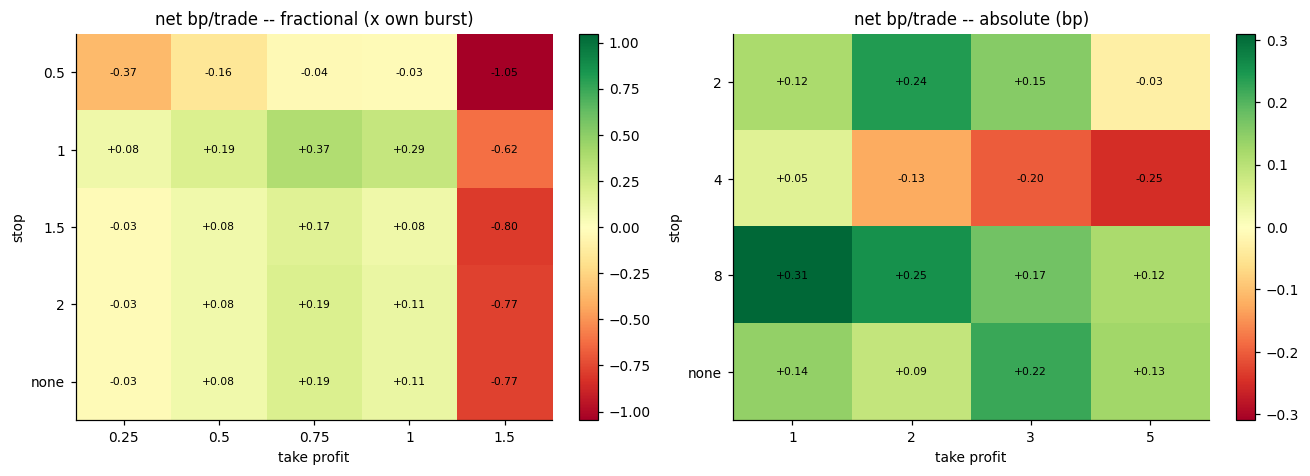

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for ax, (sw, tps, sls, tag) in zip(axes, [
        (sw_frac, FRAC_TP, FRAC_SL, "fractional (x own burst)"),
        (sw_abs,  ABS_TP,  ABS_SL,  "absolute (bp)")]):
    suffix = "f" if tag.startswith("frac") else "b"
    M = np.full((len(sls), len(tps)), np.nan)
    for i, sl in enumerate(sls):
        for j, tp in enumerate(tps):
            nm = f"tp{tp:g}{suffix}|sl{'inf' if sl is None else format(sl, 'g')}{suffix}"
            if nm in sw.index:
                M[i, j] = sw.loc[nm, "net_bp"]
    v = np.nanmax(np.abs(M)) or 1.0
    im = ax.imshow(M, cmap="RdYlGn", vmin=-v, vmax=v, aspect="auto")
    ax.set_xticks(range(len(tps))); ax.set_xticklabels([f"{t:g}" for t in tps])
    ax.set_yticks(range(len(sls))); ax.set_yticklabels(["none" if s is None else f"{s:g}" for s in sls])
    ax.set_xlabel("take profit"); ax.set_ylabel("stop")
    ax.set_title(f"net bp/trade -- {tag}"); ax.grid(False)
    for i in range(len(sls)):
        for j in range(len(tps)):
            if np.isfinite(M[i, j]):
                ax.text(j, i, f"{M[i, j]:+.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

### 6.1 The other three knobs

The burst threshold, the trailing stop and the time stop, each swept with everything else held at the
headline. A knob whose marginal is flat is a knob that is not doing anything, and saying so is more
useful than reporting its best cell.

In [13]:
THRESHOLDS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
rows = []
for thr in THRESHOLDS:
    cfg = C.spec(f"{NAME}|mv{thr:g}", instrument=INSTRUMENT, events=EVENTS, timing=TIMING,
                 signal={**SIGNAL, "min_move_bp": thr})
    bk = X.build_base_book(cfg, raw)
    if bk.events.empty:
        continue
    df = MX.run_bracket_fast(bk, RULE, cost_bp=COST_BP)
    if df.empty:
        continue
    rows.append({**stats_of(df, f"min_move >= {thr:g}bp"), "threshold": thr})
thr_tbl = pd.DataFrame(rows).set_index("label")
print("-- burst threshold --")
print(thr_tbl[["trades", "net_bp", "hit_rate", "sr_per_trade", "t_stat"]].round(4).to_string())

rows = []
for ts in [30, 58, 118, 238]:
    for tr in [None, 2.0, 4.0]:
        r = X.ExitRule(name=f"t{ts}|tr{'-' if tr is None else format(tr, 'g')}",
                       tp_frac=BRACKET["tp_frac"], sl_frac=BRACKET["sl_frac"],
                       trail_bp=tr, time_stop_min=ts, mode="close")
        # the HEADLINE book, not the threshold loop's leftover `bk`
        df = MX.run_bracket_fast(book, r, cost_bp=COST_BP)
        if not df.empty:
            rows.append({**stats_of(df, r.name), "time_stop": ts,
                         "trail": np.nan if tr is None else tr})
tt = pd.DataFrame(rows).set_index("label")
print("\n-- time stop x trailing stop --")
print(tt[["trades", "net_bp", "hit_rate", "sr_per_trade", "pct_stop", "pct_time"]].round(4).to_string())

-- burst threshold --
                   trades  net_bp  hit_rate  sr_per_trade  t_stat
label                                                            
min_move >= 0bp        84 -0.2346    0.5833       -0.0848 -0.7768
min_move >= 0.5bp      69 -0.1925    0.6377       -0.0635 -0.5273
min_move >= 1bp        60 -0.0757    0.7167       -0.0235 -0.1822
min_move >= 2bp        46  0.0132    0.7174        0.0036  0.0248
min_move >= 3bp        38 -0.0322    0.6842       -0.0082 -0.0508
min_move >= 5bp        26  0.2605    0.6538        0.0613  0.3128



-- time stop x trailing stop --
          trades  net_bp  hit_rate  sr_per_trade  pct_stop  pct_time
label                                                               
t30|tr-       38 -0.1899    0.6053       -0.0627    0.0263    0.4474
t30|tr2       38  0.0303    0.5263        0.0126    0.4474    0.0526
t30|tr4       38 -0.1782    0.6053       -0.0628    0.2368    0.2368
t58|tr-       38 -0.2169    0.7105       -0.0630    0.0526    0.4211
t58|tr2       38 -0.0011    0.5263       -0.0005    0.5000    0.0000
t58|tr4       38 -0.1892    0.6316       -0.0643    0.2895    0.1842
t118|tr-      38 -0.0322    0.6842       -0.0082    0.0526    0.2632
t118|tr2      38 -0.0011    0.5263       -0.0005    0.5000    0.0000
t118|tr4      38 -0.2026    0.6053       -0.0662    0.3684    0.0263
t238|tr-      38  0.0235    0.7105        0.0060    0.0526    0.2368
t238|tr2      38 -0.0011    0.5263       -0.0005    0.5000    0.0000
t238|tr4      38 -0.2434    0.6053       -0.0789    0.3684    0.0263


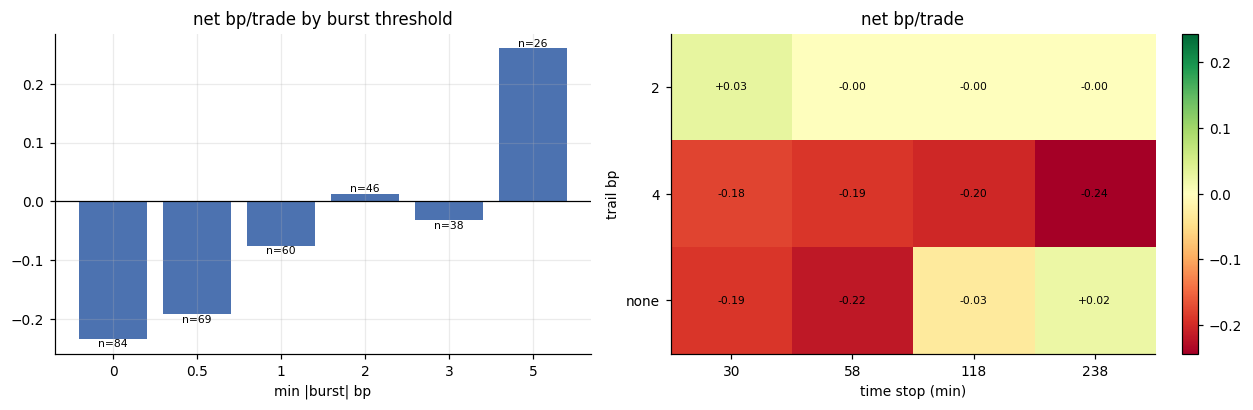

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].bar(range(len(thr_tbl)), thr_tbl["net_bp"], color="#4c72b0")
ax[0].set_xticks(range(len(thr_tbl)))
ax[0].set_xticklabels([f"{t:g}" for t in thr_tbl["threshold"]], rotation=0)
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_xlabel("min |burst| bp")
ax[0].set_title("net bp/trade by burst threshold")
for i, (v, n) in enumerate(zip(thr_tbl["net_bp"], thr_tbl["trades"])):
    ax[0].text(i, v, f"n={n}", ha="center", va="bottom" if v >= 0 else "top", fontsize=7)

piv = tt.pivot_table(index="trail", columns="time_stop", values="net_bp", dropna=False)
v = np.nanmax(np.abs(piv.to_numpy())) or 1.0
im = ax[1].imshow(piv.to_numpy(), cmap="RdYlGn", vmin=-v, vmax=v, aspect="auto")
ax[1].set_xticks(range(piv.shape[1])); ax[1].set_xticklabels(piv.columns)
ax[1].set_yticks(range(piv.shape[0])); ax[1].set_yticklabels(["none" if np.isnan(i) else f"{i:g}" for i in piv.index])
ax[1].set_xlabel("time stop (min)"); ax[1].set_ylabel("trail bp"); ax[1].grid(False)
ax[1].set_title("net bp/trade")
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        if np.isfinite(piv.to_numpy()[i, j]):
            ax[1].text(j, i, f"{piv.to_numpy()[i, j]:+.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.show()

## 7. The yardstick — the same sweep on days with no CPI

A grid returns an order statistic. Run enough brackets on noise and the best one looks excellent, so
"is the best cell good?" is answered against **the same sweep on the wrong day**, not against zero.

The placebo shifts each release by one business day onto a minute where nothing printed — business
days because CPI is never on a weekend, and shifted in New York time so the time of day survives DST.

In [15]:
real_sw = pd.concat([sw_frac, sw_abs])

placebo_raw = C.placebo_shift(raw, days=1, business_days=True, avoid_real=True)
pb_book = X.build_base_book(C.spec(f"{NAME}|placebo", instrument=INSTRUMENT, events=EVENTS,
                                   timing=TIMING, signal=SIGNAL), placebo_raw)
print(f"placebo book, SAME gate (min_move >= {SIGNAL['min_move_bp']:g}bp): "
      f"{len(pb_book.events):,} events   vs real {len(book.events):,}")
print()
print("That collapse is not a failure of the placebo -- it IS the release effect.")
print("A 3bp burst in a given minute is ordinary after CPI and rare without it, so holding")
print("the burst gate fixed leaves the control with almost nothing to trade.")

# Which also means the gated placebo cannot supply a sweep to compare against, so
# the yardstick is run a SECOND time with the burst gate opened. That is a
# different question -- "is a bracket on a quiet minute worth anything" rather
# than "is a bracket on a quiet 3bp minute worth anything" -- and it is labelled
# as such rather than quietly substituted for the first.
pb_open = X.build_base_book(
    C.spec(f"{NAME}|placebo|open", instrument=INSTRUMENT, events=EVENTS, timing=TIMING,
           signal={**SIGNAL, "min_move_bp": 0.0}), placebo_raw)
print(f"\nplacebo book, gate OPENED to 0bp: {len(pb_open.events):,} events")

sw_frac_p, ser_frac_p = sweep(pb_open, frac_shapes)
sw_abs_p,  ser_abs_p  = sweep(pb_open, abs_shapes)
pb_sw = pd.concat([sw_frac_p, sw_abs_p])
assert len(pb_sw), "the opened placebo produced no cells either -- check the bar cache"

cmp_ = pd.DataFrame([
    {"grid": "REAL CPI", "cells": len(real_sw), "median net_bp": real_sw.net_bp.median(),
     "BEST net_bp": real_sw.net_bp.max(), "BEST sr/trade": real_sw.sr_per_trade.max(),
     "% net positive": float((real_sw.net_bp > 0).mean())},
    {"grid": "placebo +1bd (0bp gate)", "cells": len(pb_sw), "median net_bp": pb_sw.net_bp.median(),
     "BEST net_bp": pb_sw.net_bp.max(), "BEST sr/trade": pb_sw.sr_per_trade.max(),
     "% net positive": float((pb_sw.net_bp > 0).mean())},
]).set_index("grid")
print()
print(cmp_.round(4).to_string())
print()
if real_sw.net_bp.max() <= pb_sw.net_bp.max():
    print("The best REAL bracket does not beat the best PLACEBO bracket.")
    print("The sweep found the shape of a sweep, not an edge.")
else:
    print(f"Best real exceeds best placebo by {real_sw.net_bp.max() - pb_sw.net_bp.max():+.4f} bp/trade")
    print("-- which is one draw against one draw. Section 8 prices how much that is worth.")

placebo book, SAME gate (min_move >= 3bp): 0 events   vs real 38

That collapse is not a failure of the placebo -- it IS the release effect.
A 3bp burst in a given minute is ordinary after CPI and rare without it, so holding
the burst gate fixed leaves the control with almost nothing to trade.

placebo book, gate OPENED to 0bp: 24 events



                         cells  median net_bp  BEST net_bp  BEST sr/trade  % net positive
grid                                                                                     
REAL CPI                    41         0.0819       0.3732         0.1140          0.6098
placebo +1bd (0bp gate)     41        -0.3012      -0.1048        -0.0803          0.0000

Best real exceeds best placebo by +0.4780 bp/trade
-- which is one draw against one draw. Section 8 prices how much that is worth.


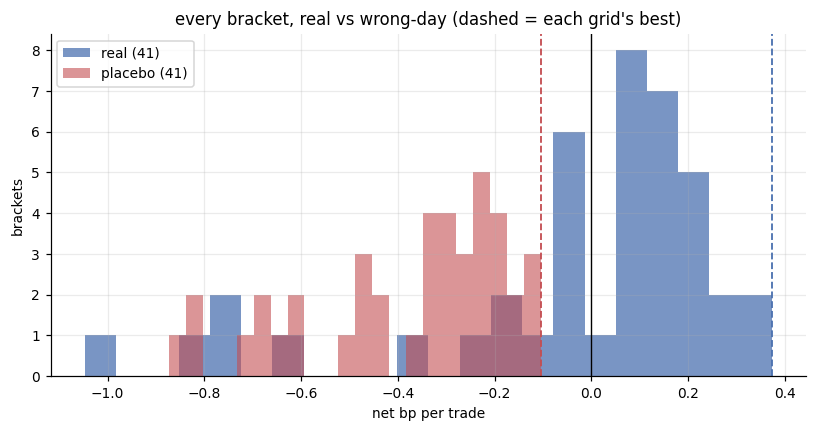

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(real_sw.net_bp, bins=22, alpha=0.75, label=f"real ({len(real_sw)})", color="#4c72b0")
ax.hist(pb_sw.net_bp, bins=22, alpha=0.6, label=f"placebo ({len(pb_sw)})", color="#c44e52")
ax.axvline(0, color="k", lw=0.9)
ax.axvline(real_sw.net_bp.max(), color="#4c72b0", ls="--", lw=1.2)
ax.axvline(pb_sw.net_bp.max(), color="#c44e52", ls="--", lw=1.2)
ax.set_xlabel("net bp per trade"); ax.set_ylabel("brackets")
ax.set_title("every bracket, real vs wrong-day (dashed = each grid's best)")
ax.legend()
plt.show()

## 8. What the search cost

Every cell above is a try, and trying is not free. Three corrections, all from
`RVUtils.StatisticalFinance`:

- **Selection-bias p** — how often a null family of this size and correlation produces a maximum this
  good. This is the number that prices the search.
- **Romano–Wolf** — a stepdown that controls the familywise error rate across all cells at once.
- **Rademacher Anti-Serum** — a high-probability lower bound on true performance after the search.

The null is a **shared** sign flip across cells, which preserves the correlation between brackets. An
independent flip per cell would pretend they were separate experiments and produce a p-value that is
far too kind.

In [17]:
ser_all = {**ser_frac, **ser_abs}
Xm = pd.DataFrame(ser_all).sort_index()
obs = np.array([Xm[c].dropna().mean() / Xm[c].dropna().std(ddof=1)
                if Xm[c].notna().sum() > 1 else 0.0 for c in Xm.columns])

null = shared_sign_flip_null(Xm, draws=2000, rng=np.random.default_rng(20260811))
p_best = selection_bias_pvalue(obs, null)
rw = romano_wolf(obs, null, alpha=0.05, names=list(Xm.columns))
ras = ras_bound(Xm.fillna(0.0), delta=0.05, draws=2000,
                rng=np.random.default_rng(7), names=list(Xm.columns))

print(f"family matrix: {Xm.shape[1]:,} brackets x {Xm.shape[0]:,} CPI prints")
print(f"selection-bias adjusted p for the BEST cell : {p_best:.4f}")
print(f"Romano-Wolf rejects at 5% FWER              : {rw.n_rejected:,} of {rw.n_strategies:,}")
print(f"Rademacher positive                         : {int((ras.bound > 0).sum()):,} of {ras.N:,}")
print()
print(ras.terms().round(5).to_string())

family matrix: 41 brackets x 38 CPI prints
selection-bias adjusted p for the BEST cell : 0.6912
Romano-Wolf rejects at 5% FWER              : 0 of 41
Rademacher positive                         : 0 of 41

empirical Sharpe (best)                0.11404
R_hat                                  0.17994
complexity penalty 2*R_hat             0.35988
sampling error 3*sqrt(2ln(2/d)/T)      1.32188
multiple testing sqrt(2ln(2N/d)/T)     0.62418
total haircut                          2.30594
best RAS lower bound                  -2.19190
T                                     38.00000
N                                     41.00000
delta                                  0.05000


In [18]:
best_nm = real_sw.sr_per_trade.idxmax()
s = Xm[best_nm].dropna().to_numpy(float)
tp = timer_pvalue(s, np.sign(s + 1e-12), draws=4999, rng=np.random.default_rng(3))
print(f"best cell by Sharpe/trade: {best_nm}")
print(real_sw.loc[[best_nm]][["trades", "net_bp", "hit_rate", "payoff", "sr_per_trade",
                              "t_stat", "pct_target", "pct_stop", "pct_time"]].round(4).to_string())
print(f"\ntimer p-value (is the TIMING of this rule better than a random reshuffle?): "
      f"{tp.p_value:.4f}   [observed {tp.observed:+.4f} vs null mean {tp.null_mean:+.4f}, "
      f"{tp.n_draws:,} draws]")
rw_row = rw.table[rw.table.strategy == best_nm]
if len(rw_row):
    print(f"Romano-Wolf adjusted p for this cell: {float(rw_row.iloc[0]['p_adjusted']):.4f}")

best cell by Sharpe/trade: tp1b|sl8b
           trades  net_bp  hit_rate  payoff  sr_per_trade  t_stat  pct_target  pct_stop  pct_time
label                                                                                            
tp1b|sl8b      38  0.3096    0.8421  0.2593         0.114   0.703      0.8421    0.0526    0.1053

timer p-value (is the TIMING of this rule better than a random reshuffle?): 1.0000   [observed +0.1140 vs null mean +0.5601, 4,999 draws]
Romano-Wolf adjusted p for this cell: 0.6912


## 9. Where this sits in the full committed search

The sweep above is a slice — one threshold, one direction, one time stop family. `cpi_ty_exit_search.py`
ran the whole product (4,920 eligible cells) and its results are committed, so the headline can be
placed against every bracket that was actually tried rather than against the handful re-run here.

In [19]:
p = G.CACHE / "cpi_ty_exit_search_real.csv"
if p.exists():
    full = pd.read_csv(p)
    full = full[full.trades >= 30]
    print(f"committed search: {len(full):,} eligible cells")
    print("\ntop 10 by net bp/trade")
    print(full.sort_values("net_bp", ascending=False).head(10)[
        ["config", "trades", "net_bp", "hit_rate", "sr_per_trade", "t_stat"]].round(4).to_string(index=False))
    print("\nmarginals -- median net bp by knob")
    for col in ("direction", "threshold", "trail", "time_stop"):
        if col in full.columns:
            g = full.groupby(col, dropna=False).agg(
                cells=("net_bp", "size"), median_net=("net_bp", "median"),
                best_net=("net_bp", "max")).round(4)
            print(f"\n-- {col} --"); print(g.to_string())
else:
    print(f"{p.name} not present -- run cpi_ty_exit_search.py to regenerate")

committed search: 4,920 eligible cells

top 10 by net bp/trade
                              config  trades  net_bp  hit_rate  sr_per_trade  t_stat
   momentum|mv3|tp3b|slinfb|tr-|t118      38  0.8124    0.6842        0.2722  1.6777
momentum|mv3|tp0.25f|slinff|tr-|t118      38  0.7244    0.7632        0.2788  1.7189
momentum|mv3|tp0.25f|sl1.5f|tr-|t118      38  0.7244    0.7632        0.2788  1.7189
  momentum|mv3|tp0.25f|sl2f|tr-|t118      38  0.7244    0.7632        0.2788  1.7189
   momentum|mv3|tp5b|slinfb|tr-|t238      38  0.6856    0.6053        0.1384  0.8533
   momentum|mv3|tp3b|slinfb|tr-|t238      38  0.6595    0.6842        0.1748  1.0775
   momentum|mv3|tp5b|slinfb|tr-|t118      38  0.5769    0.6053        0.1405  0.8663
momentum|mv2|tp0.25f|sl1.5f|tr-|t118      46  0.5748    0.7609        0.2311  1.5675
 momentum|mv3|tp0.5f|slinff|tr-|t118      38  0.5692    0.6316        0.1555  0.9588
   momentum|mv3|tp0.5f|sl2f|tr-|t118      38  0.5692    0.6316        0.1555  0.9588

m


-- threshold --
           cells  median_net  best_net
threshold                             
0.0          984     -0.2584    0.3228
0.5          984     -0.2226    0.2898
1.0          984     -0.2129    0.4175
2.0          984     -0.1653    0.5748
3.0          984     -0.1812    0.8124

-- trail --
       cells  median_net  best_net
trail                             
2.0     1640     -0.3074    0.4135
4.0     1640     -0.2919    0.3409
NaN     1640     -0.1472    0.8124

-- time_stop --
           cells  median_net  best_net
time_stop                             
30          1230     -0.2332    0.3329
58          1230     -0.2169    0.3940
118         1230     -0.2057    0.8124
238         1230     -0.2306    0.6856


## 10. Verdict

Read this notebook in the order the numbers were produced, not in the order they flatter:

1. The **tie-out** in §4 is what makes anything after it admissible. It passed here; it did not the
   first time it ran.
2. The **placebo** in §7 is the only comparison that can say the sweep found something. The best real
   bracket has to beat the best wrong-day bracket, and one draw against one draw is weak evidence
   either way.
3. The **selection-bias p** in §8 is what the search cost. A grid this size produces a good-looking
   maximum on noise, and that p-value is how often.

The exit rule is a genuine improvement in *shape* — a level exit ends most trades at a target rather
than at a bell, and the hold time collapses. Whether that shape is worth a round trip is what §7 and
§8 answer, and neither of them is impressed by a heatmap.